In [1]:
#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline

from matplotlib.backends.backend_pdf import PdfPages  # For saving multiple plots to PDF

In [2]:
def build_dqr_table(df, columns, csv_filename):
    """
    Build and save a Data Quality Report table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
    columns : Index
        Features to include
    csv_filename : str
        Output filename
    
    Returns:
    --------
    pandas.DataFrame
        Complete DQR table
    """
    stats = df[columns].describe().T
    perc_missing = 100 * (df[columns].isnull().sum() / len(df))
    cardinality = df[columns].nunique()
    
    dqr_table = pd.concat([
        stats,
        pd.DataFrame(perc_missing, columns=['%missing']),
        pd.DataFrame(cardinality, columns=['cardinality'])
    ], axis=1)
    
    dqr_table.to_csv(csv_filename, index_label='Feature')
    return dqr_table


print("✓ Helper function loaded successfully")

✓ Helper function loaded successfully


In [3]:
# Reading from a csv file, into a data frame with error handling
try:
    # If the csv file has any special symbols, it helps to specify the file encoding.
    df = pd.read_csv('ppr-group-25204989-train.csv', 
                     keep_default_na=True, 
                     delimiter=',', 
                     skipinitialspace=True)
    
    print(f"✓ Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
    
    # Show the first few rows in the data frame
    display(df.head(5))
    
except FileNotFoundError:
    print("ERROR: The file 'ppr-group-25204989-train.csv' was not found.")
    print("Please ensure the file is in the current working directory.")
except Exception as e:
    print(f"ERROR: An unexpected error occurred: {e}")

✓ Successfully loaded dataset with 54000 rows and 9 columns


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,04/07/2016,"9 AL UISCE, ENNISCORTHY, CO WEXFORD",Wexford,NaN,"€62,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,21/12/2016,"2 BEECHVILLE, THE LOUTH, CORK",Cork,NaN,"€150,000.00",Yes,No,Second-Hand Dwelling house /Apartment,NaN
2,23/08/2016,"75 BELLEFIELD RD, ENNISCORTHY, WEXFORD",Wexford,NaN,"€94,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,23/02/2016,"No. 6, St. Caillins View, Fenagh",Leitrim,NaN,"€149,500.00",No,Yes,New Dwelling house /Apartment,greater than 125 sq metres
4,07/10/2016,"NO7 GRATTAN PARK, CONVENT RD, CLAREMORRIS",Mayo,NaN,"€170,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


## Data Validation
The main issue identified is the presence of 4 duplicate rows.

In [4]:
# Validate that the dataframe has data and expected columns

print("Dataset Validation Checks:")
print("="*60)

# Check 1: Dataset is not empty
if df.empty:
    print("⚠ WARNING: Dataset is empty!")
else:
    print(f"✓ Dataset contains {df.shape[0]:,} rows")

# Check 2: Check for duplicate rows
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"⚠ WARNING: Found {duplicate_count} duplicate rows")
else:
    print("✓ No duplicate rows found")

# Check 3: Check if all columns are unnamed
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    print(f"⚠ WARNING: Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")
else:
    print("✓ All columns have names")

# Check 4: Basic column overview
print(f"\n✓ Dataset has {df.shape[1]} columns:")
print(f"  - Column names: {list(df.columns)}")

Dataset Validation Checks:
✓ Dataset contains 54,000 rows
⚠ WARNING: Found 4 duplicate rows
✓ All columns have names

✓ Dataset has 9 columns:
  - Column names: ['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description']


In [5]:
# Check how many rows and columns this dataframe has
print(f"Dataset shape: {df.shape}")
print(f"Number of rows (instances): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

Dataset shape: (54000, 9)
Number of rows (instances): 54000
Number of columns (features): 9


In [6]:
df.dtypes

Date of Sale (dd/mm/yyyy)    object
Address                      object
County                       object
Eircode                      object
Price (€)                    object
Not Full Market Price        object
VAT Exclusive                object
Description of Property      object
Property Size Description    object
dtype: object

In [7]:
pd.set_option("display.precision", 2)
df.describe().T

,count,unique,top,freq
Date of Sale (dd/mm/yyyy),54000,2482,20/12/2018,104
Address,54000,53357,"KNOCKNAGEEHA, NEWPORT, MAYO",3
County,54000,26,Dublin,16679
Eircode,16817,16761,A96WV79,4
Price (€),54000,6871,"€150,000.00",595
Not Full Market Price,54000,2,No,51172
VAT Exclusive,54000,2,No,44299
Description of Property,54000,3,Second-Hand Dwelling house /Apartment,44143
Property Size Description,2848,4,greater than or equal to 38 sq metres and less...,2073


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54000 entries, 0 to 53999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Date of Sale (dd/mm/yyyy)  54000 non-null  object
 1   Address                    54000 non-null  object
 2   County                     54000 non-null  object
 3   Eircode                    16817 non-null  object
 4   Price (€)                  54000 non-null  object
 5   Not Full Market Price      54000 non-null  object
 6   VAT Exclusive              54000 non-null  object
 7   Description of Property    54000 non-null  object
 8   Property Size Description  2848 non-null   object
dtypes: object(9)
memory usage: 3.7+ MB


## Correct feature data types
Price should be a numeric feature. However, it contains the "€" symbol. Need to delete the "€" and change its type to float.<br>
Other features are set to be "category".

In [9]:
# Correct feature data types

# change the price feature as numeric. 

df['Price (€)'] = df['Price (€)'].astype(str).str.replace('€', '', regex=False).str.replace(',', '').astype(float)

# Convert all object columns to categorical
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')


# Update column groups after type corrections
numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns

print("✓ Data types corrected:")
print(f"  - Numeric features: {len(numeric_columns)}")
print(f"  - Categorical features: {len(category_columns)}")

# Save changed data (the price) into new csv file
df.to_csv('ppr-group-25204989-train-v1.csv',index=False)

✓ Data types corrected:
  - Numeric features: 1
  - Categorical features: 8


In [10]:
# Usage:
df_numeric_dqr = build_dqr_table(df, numeric_columns, 
                                  'tables_plots/ppr-group-25204989-train-NumericFeatures-Summary-Table.csv')
display(df_numeric_dqr)

,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
Price (€),54000.0,330160.11,1.39e+06,5250.0,158000.0,250912.5,365000.0,2.22e+08,0.0,6871


In [11]:
df_categorical_dqr = build_dqr_table(df, category_columns, 
                                  'tables_plots/ppr-group-25204989-train-CategoricalFeatures-Summary-Table.csv')
display(df_categorical_dqr)

,count,unique,top,freq,%missing,cardinality
Date of Sale (dd/mm/yyyy),54000,2482,20/12/2018,104,0.00,2482
Address,54000,53357,"ADDINSTOWN, DELVIN, WESTMEATH",3,0.00,53357
County,54000,26,Dublin,16679,0.00,26
Eircode,16817,16761,A96WV79,4,68.86,16761
Not Full Market Price,54000,2,No,51172,0.00,2
VAT Exclusive,54000,2,No,44299,0.00,2
Description of Property,54000,3,Second-Hand Dwelling house /Apartment,44143,0.00,3
Property Size Description,2848,4,greater than or equal to 38 sq metres and less...,2073,94.73,4


## Change type of "Date of Sale (dd/mm/yyyy)",  "Address" and "Eircode"
"Date of Sale (dd/mm/yyyy)", "Address" and "Eircode" have too many unique values and fail to generate category-feature plots. So they are set to be object before generating plots.

In [12]:
df.columns = df.columns.str.replace(' ', '')
df['Address']=df['Address'].astype('object')
df['Eircode']=df['Eircode'].astype('object')
df['DateofSale(dd/mm/yyyy)']=df['DateofSale(dd/mm/yyyy)'].astype('object')


numeric_columns = df.select_dtypes(['int64', 'float64']).columns
category_columns = df.select_dtypes('category').columns
object_columns=df.select_dtypes('object').columns

# Summary: Show feature categorization results
print("="*70)
print("FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT")
print("="*70)
print(f"\n✓ Numeric features ({len(numeric_columns)}):")
print(f"   {list(numeric_columns)}")
print(f"\n✓ Categorical features ({len(category_columns)}):")
print(f"   {list(category_columns)}")
print(f"\n✓ object features({len(object_columns)})")
print(f"   {list(object_columns)}")
print("\n" + "="*70)

FEATURE TYPES CONFIGURED FOR DATA QUALITY ASSESSMENT

✓ Numeric features (1):
   ['Price(€)']

✓ Categorical features (5):
   ['County', 'NotFullMarketPrice', 'VATExclusive', 'DescriptionofProperty', 'PropertySizeDescription']

✓ object features(3)
   ['DateofSale(dd/mm/yyyy)', 'Address', 'Eircode']



In [13]:
# Set plot styling for readability
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

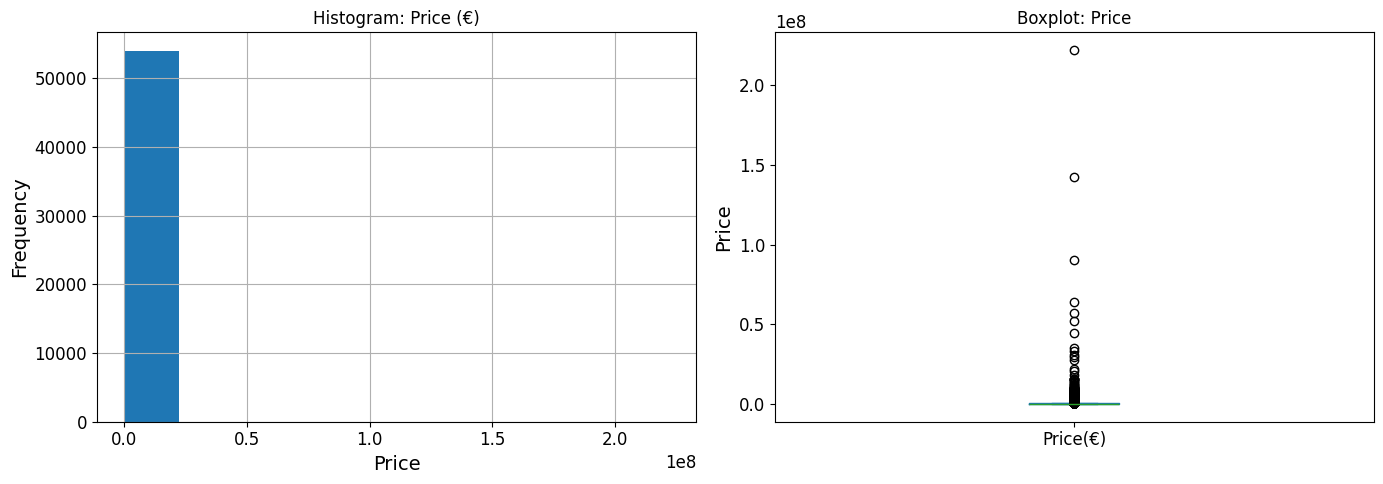

In [14]:
# Create subplots for histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df['Price(€)'].hist(ax=axes[0])
axes[0].set_title('Histogram: Price (€)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Boxplot
df['Price(€)'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot: Price')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('tables_plots/ppr-group-25204989-train-NumericFeatures-histogram.pdf')
plt.show()


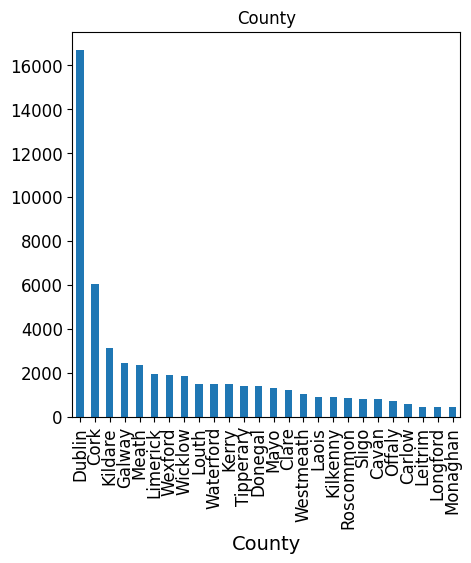

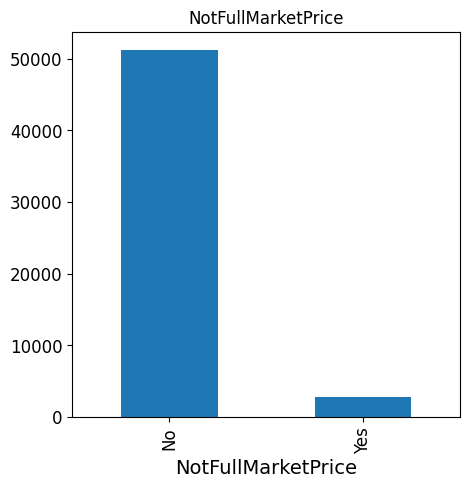

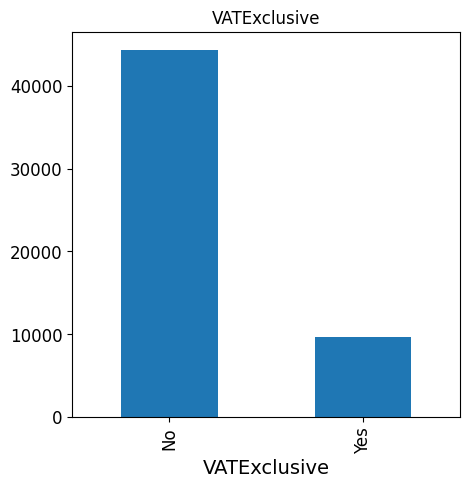

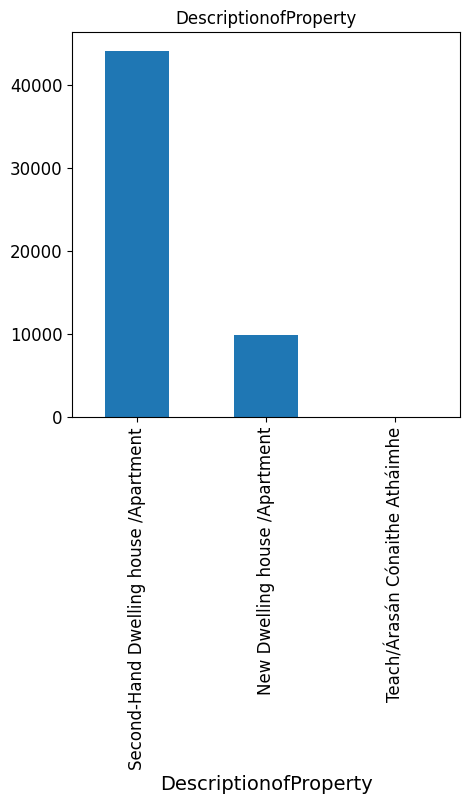

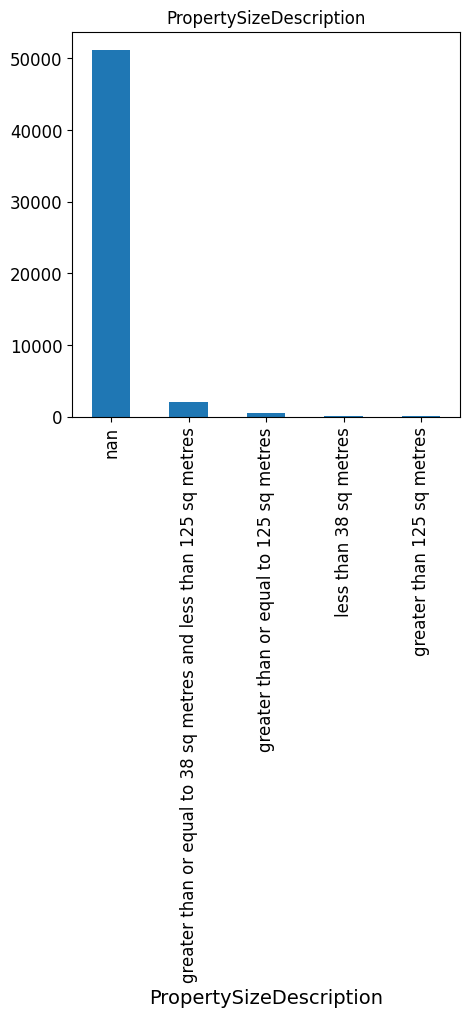

In [15]:
# Bar charts for all categorical features (saved to a single PDF)
# dropna=False keeps missing values visible
pp = PdfPages('tables_plots/ppr-group-25204989-train-CategoricalFeatures_barcharts_1-1.pdf')

for column in category_columns:
    f = df[column].value_counts(dropna=False).plot(kind='bar', title=column, figsize=(5,5))
    pp.savefig(f.get_figure())
    plt.show()

pp.close()

In [16]:
# Create a comprehensive summary for each group: numeric and categorical features
print("="*80)
print("DATA QUALITY SUMMARY")
print("="*80)
print(f"\nTotal Features: {len(numeric_columns) + len(category_columns)}")
print(f"  - Numeric Features: {len(numeric_columns)}")
print(f"  - Categorical Features: {len(category_columns)}")
print(f"\n✓ Numeric summary saved to 'ppr-group-25204989-train-NumericFeatures-Summary-Table.csv'")
print(f"✓ Categorical summary saved to 'ppr-group-25204989-train-CategoricalFeatures-Summary-Table.csv'")

display(df_numeric_dqr)
display(df_categorical_dqr)

DATA QUALITY SUMMARY

Total Features: 6
  - Numeric Features: 1
  - Categorical Features: 5

✓ Numeric summary saved to 'ppr-group-25204989-train-NumericFeatures-Summary-Table.csv'
✓ Categorical summary saved to 'ppr-group-25204989-train-CategoricalFeatures-Summary-Table.csv'


,count,mean,std,min,25%,50%,75%,max,%missing,cardinality
Price (€),54000.0,330160.11,1.39e+06,5250.0,158000.0,250912.5,365000.0,2.22e+08,0.0,6871


,count,unique,top,freq,%missing,cardinality
Date of Sale (dd/mm/yyyy),54000,2482,20/12/2018,104,0.00,2482
Address,54000,53357,"ADDINSTOWN, DELVIN, WESTMEATH",3,0.00,53357
County,54000,26,Dublin,16679,0.00,26
Eircode,16817,16761,A96WV79,4,68.86,16761
Not Full Market Price,54000,2,No,51172,0.00,2
VAT Exclusive,54000,2,No,44299,0.00,2
Description of Property,54000,3,Second-Hand Dwelling house /Apartment,44143,0.00,3
Property Size Description,2848,4,greater than or equal to 38 sq metres and less...,2073,94.73,4


## Identify Outliers in Price
Pick out the outliers to decide how to deal with it. There is no lower outlier, and there are 3009 high outliers, around 5.57% in total. 

In [17]:
# get low outliers
lower_bound = 158000 - 1.5 * (365000-158000)
upper_bound = 365000 + 1.5 * (365000-158000)
low_outliers_iqr = df[(df['Price(€)'] < lower_bound)] 
print(f"Number of outliers: {len(low_outliers_iqr)}")
print("="*80)
low_outliers_iqr

Number of outliers: 0


,DateofSale(dd/mm/yyyy),Address,County,Eircode,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,PropertySizeDescription


In [18]:
# get high outliers
high_outliers_iqr = df[(df['Price(€)'] > upper_bound)] 
print(f"Number of outliers: {len(high_outliers_iqr)}")
percentage=round(len(high_outliers_iqr)/df.shape[0],4)*100
print (f"Percentage of outliers: {percentage}%")
print("="*80)
high_outliers_iqr

Number of outliers: 3009
Percentage of outliers: 5.57%


,DateofSale(dd/mm/yyyy),Address,County,Eircode,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,PropertySizeDescription
107,26/07/2016,"Ard Mor, 31 Granville Park, Blackrock",Dublin,NaN,9.91e+05,No,Yes,New Dwelling house /Apartment,greater than 125 sq metres
110,23/12/2016,"31 GREEN ROAD, BLACKROCK, CO DUBLIN",Dublin,NaN,1.02e+06,No,No,Second-Hand Dwelling house /Apartment,NaN
154,09/11/2016,"29 WOODLANDS PARK, BLACKROCK, DUBLIN",Dublin,NaN,2.50e+06,No,No,Second-Hand Dwelling house /Apartment,NaN
193,25/11/2016,"28 PARKVALE, SANDYFORD ROAD, DUNDRUM",Dublin,NaN,7.40e+05,No,No,Second-Hand Dwelling house /Apartment,NaN
219,20/12/2016,"4 FARMLEIGH AVE, BLACKROCK, DUBLIN",Dublin,NaN,6.98e+05,No,No,Second-Hand Dwelling house /Apartment,NaN
...,...,...,...,...,...,...,...,...,...
53937,30/09/2024,"5 Outfarm Wood Carpenterstown Rd., Castleknock...",Dublin,NaN,9.85e+05,No,Yes,New Dwelling house /Apartment,NaN
53941,15/03/2024,"79 BOTANIC RD, GLASNEVIN, DUBLIN 9",Dublin,D09P9T7,7.00e+05,No,No,Second-Hand Dwelling house /Apartment,NaN
53969,08/05/2024,"3 KENT TERRACE, BARNHILL RD, DALKEY",Dublin,A96D864,1.45e+06,No,No,Second-Hand Dwelling house /Apartment,NaN
53986,16/09/2024,"18 CARRIGLEA, KILLENARD, PORTARLINGTON",Laois,R32V9K3,6.95e+05,No,No,Second-Hand Dwelling house /Apartment,NaN


In [19]:
# Get extremes according to the boxplot. The point which separate the extreme outliers is about 0.3e+8.
extremes = df[(df['Price(€)'] > 0.3e+8)] 
print(f"Number of outliers: {len(extremes)}")
print("="*80)
extremes

Number of outliers: 10


,DateofSale(dd/mm/yyyy),Address,County,Eircode,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,PropertySizeDescription
2158,15/01/2016,"Tallaght Cross West, Tallaght",Dublin,NaN,6.41e+07,No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...
5275,24/03/2016,"APT 1 THOMOND VILLAGE, UNIVERSITY OF LIMERICK ...",Clare,NaN,3.32e+07,No,No,Second-Hand Dwelling house /Apartment,NaN
12977,18/10/2018,"28 29 30 31 and 32 Gardens Lane, 1 2 2 1/2 an...",Dublin,NaN,3.10e+07,No,Yes,New Dwelling house /Apartment,greater than or equal to 125 sq metres
18918,11/04/2019,"APT 1, 45 FRANCIS ST, DUBLIN 8",Dublin,NaN,4.44e+07,No,No,Second-Hand Dwelling house /Apartment,NaN
19728,23/12/2019,"Blocks A and C, The Point Campus",Dublin,NaN,1.42e+08,No,Yes,New Dwelling house /Apartment,NaN
23099,19/12/2019,"Houses 1-120, St Edmunds Square St Edmunds Gr...",Dublin,NaN,5.20e+07,No,Yes,New Dwelling house /Apartment,NaN
31640,21/12/2021,"37 53 39 49 and 51 Montpelier Hill, 55 rere Mo...",Dublin,D07HCN4,5.70e+07,No,No,Second-Hand Dwelling house /Apartment,NaN
33102,17/12/2021,"63 Apartments, Knockrabo, Mount Anville Road",Dublin,NaN,3.52e+07,No,Yes,New Dwelling house /Apartment,NaN
43551,07/07/2023,"Block 3, Wyckham Point, Dundrum",Dublin,D16YF90,9.01e+07,No,No,Second-Hand Dwelling house /Apartment,NaN
53440,23/12/2024,"Cooper Square, Seven Mills, Clonburris",Dublin,NaN,2.22e+08,No,Yes,New Dwelling house /Apartment,NaN


According to the rows printed out, the outliers are mostly bulk property transactions. 

## Identify duplicate rows

In [20]:
all_duplicates = df[df.duplicated(keep=False)]

all_duplicates

,DateofSale(dd/mm/yyyy),Address,County,Eircode,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,PropertySizeDescription
814,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,NaN,140000.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
2752,27/09/2016,"LISNANAGH, EDGEWORTHSTOWN, LONGFORD",Longford,NaN,140000.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
7404,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,NaN,135000.0,No,No,Second-Hand Dwelling house /Apartment,NaN
9273,12/12/2017,"26 27 POPES QUAY, NORTH QUAY PLACE, CORK",Cork,NaN,135000.0,No,No,Second-Hand Dwelling house /Apartment,NaN
21308,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,NaN,108333.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
23994,07/01/2019,"THE COACH HOUSE, CIRCULAR RD, DUNMORE EAST",Waterford,NaN,108333.0,Yes,No,Second-Hand Dwelling house /Apartment,NaN
48514,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,D13N5XF,570000.0,No,No,Second-Hand Dwelling house /Apartment,NaN
49945,12/01/2024,"29 KING STREET, BELLTREE, CLONGRIFFIN",Dublin,D13N5XF,570000.0,No,No,Second-Hand Dwelling house /Apartment,NaN


### Summary of Data Quality Issues


| Feature | Type | Data Quality Issue(s) | Impact | Root Cause Analysis | Proposed Solution | Final Action |
|---------|------|----------------------|--------|-------------------|------------------|--------------|
| **DateofSale(dd/mm/yyyy)** | object | Too much cardinality, not useful for prediction.| High | Natural records of dates| Extract year and month  |   |
| **Address** | object | Too much cardinality, not useful for prediction. | High | Natural records of different properties | Investigate whether it can be converted to eircode. If not, drop it. |  |
| **County** | category | No issue | Low | No issue | Keep  |   |
| **Eircode** | object | Too much cardinality, not useful for prediction. | High | Natural records of different properties | Try to fill it by address and extract the district from eircode. If can't, drop it.  |   |
| **Eircode** | object | Too much missing(68.86%), not useful for prediction.  | High | Data not collected | Try to fill it by address. If can't, drop it.  |   |
| **Price** | float64 | Outliers and extremes | Medium | Most high values are valid outliers but several extremes need more investigation| Clamp the price to upper bound |  |
| **NotFullMarketPrice** | category | No issue | Low | Binary categorical feature | Keep |  |
| **VATExclusive** | category | No issue | Low | Binary categorical feature | Keep |  |
| **DescriptionofProperty** | category | No issue | Low | Records of property types | Keep |  |
| **PropertySizeDescription** | category | Too much missing(97.73%), not useful for prediction. | High | Data not collected | Drop the feature |  |
| **Other** | none | 4 duplicate rows | low | recording error | Remove duplicate rows |  |

